In [18]:
import pandas as pd
import matplotlib.pyplot as plt # visualizing data
import seaborn as sns

In [19]:
df = pd.read_csv("movie_profit.csv")

In [20]:
df.head()

,Unnamed: 0,release_date,movie,production_budget,domestic_gross,worldwide_gross,distributor,mpaa_rating,genre
0,1,6/22/2007,Evan Almighty,175000000.0,100289690.0,1.741313e+08,Universal,PG,Comedy
1,2,7/28/1995,Waterworld,175000000.0,88246220.0,2.642462e+08,Universal,PG-13,Action
2,3,5/12/2017,King Arthur: Legend of the Sword,175000000.0,39175066.0,1.399507e+08,Warner Bros.,PG-13,Adventure
3,4,12/25/2013,47 Ronin,175000000.0,38362475.0,1.517168e+08,Universal,PG-13,Action
4,5,6/22/2018,Jurassic World: Fallen Kingdom,170000000.0,416769345.0,1.304866e+09,Universal,PG-13,Action


In [21]:
df.columns

Index(['Unnamed: 0', 'release_date', 'movie', 'production_budget',
       'domestic_gross', 'worldwide_gross', 'distributor', 'mpaa_rating',
       'genre'],
      dtype='object')

In [22]:
# Drop all the Unnamed Colums from the dataframe
df.drop(columns=('Unnamed: 0'), inplace=True)

In [24]:
df.head()

,release_date,movie,production_budget,domestic_gross,worldwide_gross,distributor,mpaa_rating,genre
0,6/22/2007,Evan Almighty,175000000.0,100289690.0,1.741313e+08,Universal,PG,Comedy
1,7/28/1995,Waterworld,175000000.0,88246220.0,2.642462e+08,Universal,PG-13,Action
2,5/12/2017,King Arthur: Legend of the Sword,175000000.0,39175066.0,1.399507e+08,Warner Bros.,PG-13,Adventure
3,12/25/2013,47 Ronin,175000000.0,38362475.0,1.517168e+08,Universal,PG-13,Action
4,6/22/2018,Jurassic World: Fallen Kingdom,170000000.0,416769345.0,1.304866e+09,Universal,PG-13,Action


In [28]:
df.isnull().sum()

release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
distributor          0
mpaa_rating          0
genre                0
dtype: int64

In [27]:
df.dropna(inplace=True)

In [29]:
df.duplicated().sum()

0

In [30]:
df["genre"].value_counts()

genre
Drama        1180
Comedy        775
Action        540
Adventure     469
Horror        266
Name: count, dtype: int64

In [31]:
# Finding the mean value of domestic gross in movies...
df.groupby("mpaa_rating")["domestic_gross"].mean()

mpaa_rating
G        8.253156e+07
PG       6.742011e+07
PG-13    5.487091e+07
R        3.208529e+07
Name: domestic_gross, dtype: float64

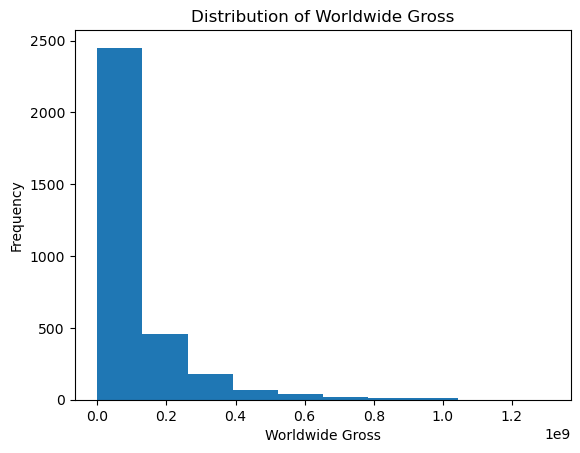

In [ ]:
# visualizing worldwide_gross value...
plt.hist(df["worldwide_gross"])
plt.title("Distribution of Worldwide Gross")
plt.xlabel("Worldwide Gross")
plt.ylabel("Frequency")
plt.show()

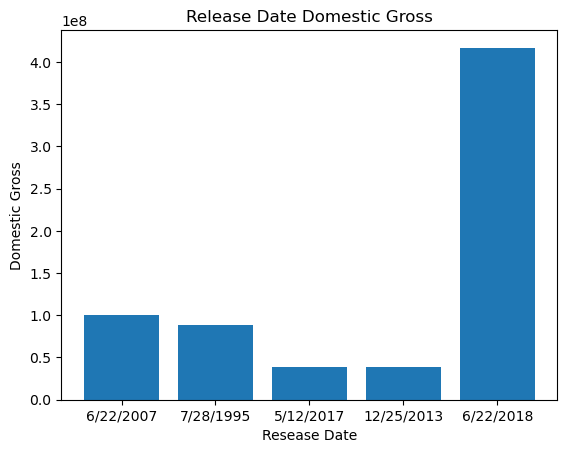

In [33]:
# visualizing domestic gross and release date in a bar plot...
plt.bar(df["release_date"].head(), df["domestic_gross"].head())
plt.title("Release Date Domestic Gross")
plt.xlabel("Resease Date")
plt.ylabel("Domestic Gross")
plt.show()

In [34]:
# group by distributor with worldwide gross to find the sume of it...
df.groupby("distributor")["worldwide_gross"].sum().sort_values(ascending= False)

distributor
Warner Bros.            4.821614e+10
20th Century Fox        4.697384e+10
Universal               4.599647e+10
Sony Pictures           3.747076e+10
Paramount Pictures      3.732193e+10
                            ...     
IFC Midnight            0.000000e+00
Codex Pictures          0.000000e+00
ESX Entertainment       0.000000e+00
Castle Hill Product…    0.000000e+00
Outrider Pictures       0.000000e+00
Name: worldwide_gross, Length: 186, dtype: float64

In [35]:
# Finding the median value of raing using the value as domestic_gross...
df.groupby("mpaa_rating")["domestic_gross"].median()

mpaa_rating
G        58611764.5
PG       48006762.0
PG-13    34522221.0
R        15934642.0
Name: domestic_gross, dtype: float64

In [36]:
# finding the max domestic gross by genre...

df.groupby("genre")["domestic_gross"].max()

genre
Action       416769345.0
Adventure    474544677.0
Comedy       285761243.0
Drama        435110554.0
Horror       327481748.0
Name: domestic_gross, dtype: float64

In [38]:
# finding the min production budget gross by rating...
df.groupby("mpaa_rating")["production_budget"].min()

mpaa_rating
G        560000.0
PG       300000.0
PG-13    250000.0
R        250000.0
Name: production_budget, dtype: float64

In [39]:
#
df.groupby("distributor")["worldwide_gross"].mean()

distributor
20th Century Fox        1.726979e+08
8X Entertainment        6.047691e+06
A24                     2.332026e+07
ARC Entertainment       2.248513e+06
Abramorama Films        5.491850e+05
                            ...     
Well Go USA             1.573010e+08
Wrekin Hill Enterta…    6.155376e+07
XLrator Media           9.270740e+05
Yari Film Group Rel…    4.352631e+07
Zeitgeist               6.173485e+06
Name: worldwide_gross, Length: 186, dtype: float64

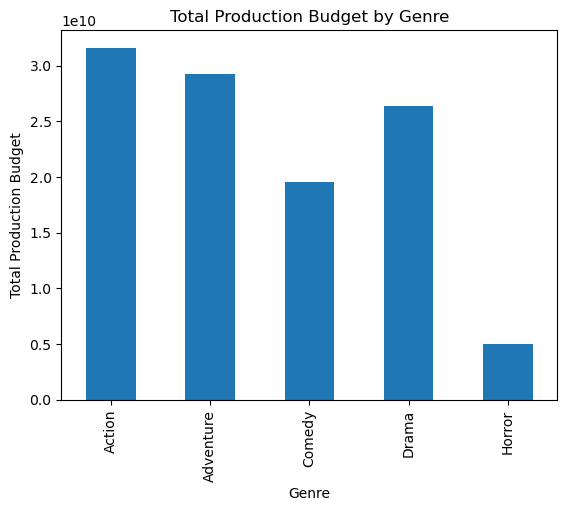

In [40]:
# visualizing Total Production Budget by Genre in bar chat...
df.groupby("genre")["production_budget"].sum().plot(kind="bar")
plt.title("Total Production Budget by Genre")
plt.xlabel("Genre")
plt.ylabel("Total Production Budget")
plt.show()

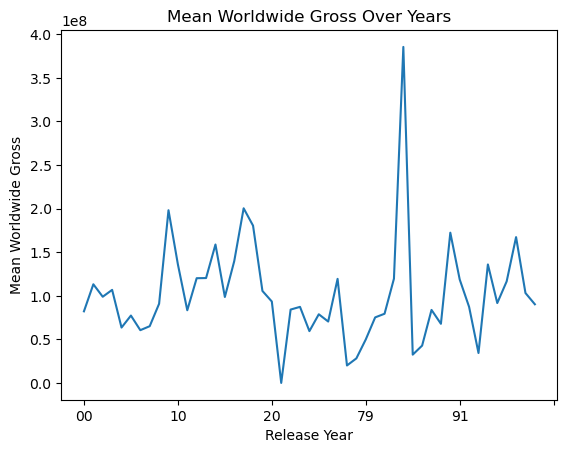

In [44]:
# visualizing Mean Worldwide Gross Over Years in a line chart...
df.groupby(df["release_date"].str.slice(6,8))["worldwide_gross"].mean().plot(kind="line")
plt.title("Mean Worldwide Gross Over Years")
plt.xlabel("Release Year")
plt.ylabel("Mean Worldwide Gross")
plt.show()

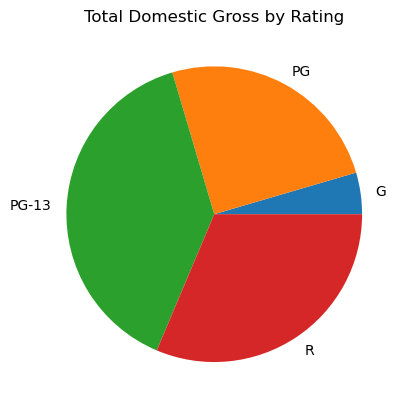

In [45]:
# visualizing the Total Domestic Gross by Rating in a pie chart...
df.groupby("mpaa_rating")["domestic_gross"].sum().plot(kind="pie")
plt.title("Total Domestic Gross by Rating")
plt.ylabel("")
plt.show()

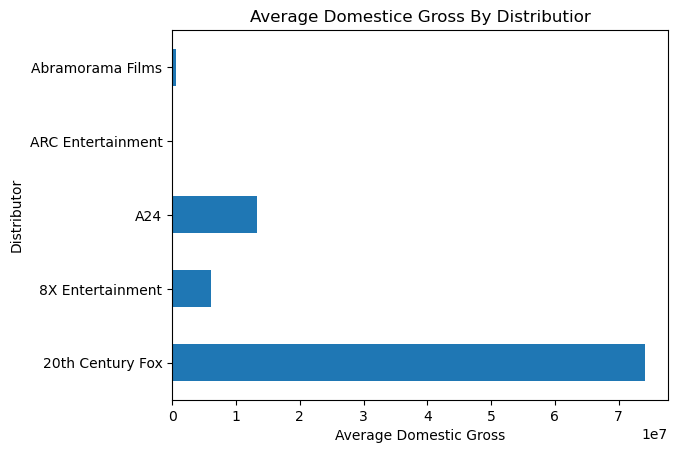

In [46]:
# visualizing the Average Domestice Gross By Distributior with bar chart in horizontal...
df.groupby("distributor")["domestic_gross"].mean().head().plot(kind="barh")
plt.title("Average Domestice Gross By Distributior")
plt.xlabel("Average Domestic Gross")
plt.ylabel("Distributor")
plt.show()